# Spotify Hit Prediction - Exploratory Data Analysis (EDA)

```
Objectif:
- Analyser les caractéristiques audio des morceaux Spotify
afin de comprendre ce qui distingue un "hit" d’un "non-hit".
- Prédire si un morceau est un hit.

Dataset:
114 000 morceaux avec features audio (Spotify API)
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

sns.set_style(style="whitegrid")

In [2]:
# Chargement le dataset Spotify Audio Features depuis Hugging Face
dataset = load_dataset("Faizasb/spotify-tracks-dataset")

# Convertir en pandas
df = dataset["train"].to_pandas()

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# I. Analyse de la forme

In [3]:
"""
Dataset chargé depuis Hugging Face puis converti en DataFrame pandas
pour faciliter l'analyse exploratoire.
"""

# Nombre de lignes et de colonnes du dataset, types de variables
print(df.shape)
df.info()

(114000, 21)
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          

In [4]:
# Données statistiques
df.describe().round(2)

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00,114000.00
mean,56999.50,33.24,228029.15,0.57,0.64,5.31,-8.26,0.64,0.08,0.31,0.16,0.21,0.47,122.15,3.90
std,32909.11,22.31,107297.71,0.17,0.25,3.56,5.03,0.48,0.11,0.33,0.31,0.19,0.26,29.98,0.43
min,0.00,0.00,0.00,0.00,0.00,0.00,-49.53,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,28499.75,17.00,174066.00,0.46,0.47,2.00,-10.01,0.00,0.04,0.02,0.00,0.10,0.26,99.22,4.00
50%,56999.50,35.00,212906.00,0.58,0.68,5.00,-7.00,1.00,0.05,0.17,0.00,0.13,0.46,122.02,4.00
75%,85499.25,50.00,261506.00,0.70,0.85,8.00,-5.00,1.00,0.08,0.60,0.05,0.27,0.68,140.07,4.00
max,113999.00,100.00,5237295.00,0.98,1.00,11.00,4.53,1.00,0.96,1.00,1.00,1.00,1.00,243.37,5.00


## 1. Typologie des variables

Les variables du dataset peuvent être classées en plusieurs catégories :

**- Variables continues**
- danceability
- energy
- loudness
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- duration_ms

**- Variables discrètes**
- key
- mode
- time_signature
- popularity

**- Variables catégorielles**
- track_genre
- artists
- album_name
- track_name

**- Variable booléenne**
- explicit

> À noter : la variable `key`, bien que codée numériquement, représente une catégorie musicale correspondant à la tonalité du morceau (Do, Ré, Mi,... avec dièses et bémols).*

## 2. Identification des valeurs manquantes et doublons

On vérifie la présence de valeurs manquantes et de doublons afin d’évaluer la qualité du dataset.

In [5]:
print(df.duplicated().sum())
df.isna().sum()

0


Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [6]:
df[df["artists"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [7]:
df = df.dropna()
df.isna().sum()

Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [8]:
df = df.drop(columns=["Unnamed: 0"])
df.duplicated().sum()

np.int64(450)

In [9]:
df[df.duplicated()]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
1925,0CDucx9lKxuCZplLXUz0iX,Buena Onda Reggae Club,Disco 2,Song for Rollins,16,219346,False,0.841,0.577,0,-7.544,1,0.0438,0.238000,0.860000,0.0571,0.843,90.522,4,afrobeat
2155,2aibwv5hGXSgw7Yru8IYTO,Red Hot Chili Peppers,Stadium Arcadium,Snow (Hey Oh),80,334666,False,0.427,0.900,11,-3.674,1,0.0499,0.116000,0.000017,0.1190,0.599,104.655,4,alt-rock
3738,7mULVp0DJrI2Nd6GesLvxn,Joy Division,Timeless Rock Hits,Love Will Tear Us Apart,0,204621,False,0.524,0.902,2,-8.662,1,0.0368,0.000989,0.695000,0.1370,0.907,146.833,4,alternative
4648,6d3RIvHfVkoOtW1WHXmbX3,Little Symphony,Serenity,Margot,27,45714,False,0.269,0.142,0,-23.695,1,0.0509,0.866000,0.904000,0.1140,0.321,67.872,3,ambient
5769,481beimUiUnMUzSbOAFcUT,SUPER BEAVER,突破口 / 自慢になりたい,突破口,54,255080,False,0.472,0.994,8,-1.786,1,0.1140,0.025900,0.000000,0.0535,0.262,103.512,4,anime
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111246,0sSjIvTvd6fUSZZ5rnTPDW,Everything But The Girl,Eden (Deluxe Edition),Another Bridge - 2012 Remaster,26,132826,False,0.480,0.853,0,-6.276,1,0.0734,0.030600,0.000001,0.3200,0.775,85.181,4,trip-hop
111362,2zg3iJW4fK7KZgHOvJU67z,Faithless,Faithless 2.0,Tarantula,21,398152,False,0.622,0.816,6,-11.095,0,0.0483,0.009590,0.578000,0.0991,0.427,136.007,4,trip-hop
111980,46FPub2Fewe7XrgM0smTYI,Morcheeba,Parts of the Process,Undress Me Now,17,203773,False,0.576,0.352,7,-10.773,0,0.0268,0.700000,0.270000,0.1600,0.360,95.484,4,trip-hop
112968,6qVA1MqDrDKfk9144bhoKp,Acil Servis,Küçük Adam,Bebek,38,319933,False,0.486,0.485,5,-12.391,0,0.0331,0.004460,0.000017,0.3690,0.353,120.095,4,turkish


In [10]:
df = df.drop_duplicates()
print(df.duplicated().sum())
print(f"Taille du dataset après nettoyage des valeurs manquantes et doublons: {df.shape}")

0
Taille du dataset après nettoyage des valeurs manquantes et doublons: (113549, 20)


**Nettoyage des données**

- La colonne `Unnamed: 0`, correspondant à un index technique, a été supprimée.

- Une ligne contenant des valeurs manquantes a également été supprimée.

- Une analyse des doublons a montré que certaines observations étaient strictement identiques (mêmes valeurs sur toutes les variables). Ces doublons ont été supprimés afin d’éviter tout biais dans l’analyse et la modélisation.

In [11]:
df.groupby("track_id").size().sort_values(ascending=False).head()

track_id
6S3JlDAGk3uu3NtZbPnuhS    9
2Ey6v4Sekh3Z0RUSISRosD    8
2kkvB3RNRzwjFdGhaUA0tz    8
5ZsAhuQ24mWHiduaxJqnhW    7
6bzWr3EpSEolVwlbLk58il    7
dtype: int64

> *Note :*
> *Plusieurs lignes partagent le même `track_id`. Les caractéristiques audio étant identiques, seule la variable `track_genre` diffère.*
> *Cela signifie qu’un même morceau peut être associé à plusieurs genres dans le dataset.*
> *Ces observations ont été conservées car elles apportent une information supplémentaire sur la classification musicale des morceaux.*

## 3. Identification de la target

### 3.1. Analyse de la variable popularity (popularité)

La variable `popularity` correspond à un score attribué par Spotify, compris entre 0 et 100.

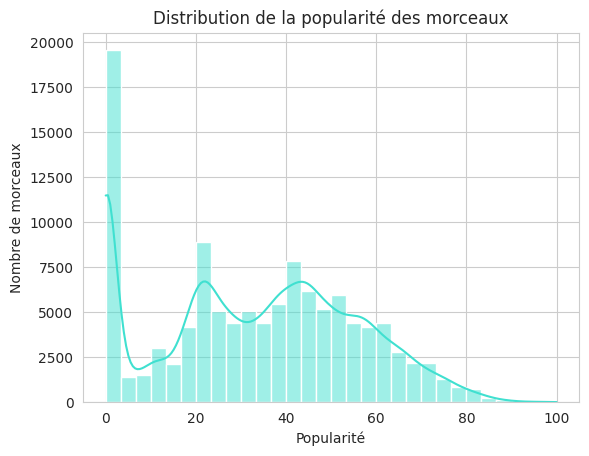

In [40]:
sns.histplot(df["popularity"], bins=30, kde=True, color = "turquoise")
plt.title("Distribution de la popularité des morceaux")
plt.xlabel("Popularité")
plt.ylabel("Nombre de morceaux")
plt.show()

In [ ]:
df["popularity"].describe().round(2)

count    113549.00
mean         33.32
std          22.28
min           0.00
25%          17.00
50%          35.00
75%          50.00
max         100.00
Name: popularity, dtype: float64

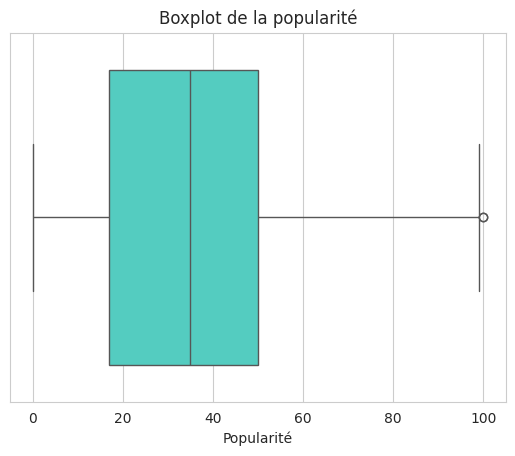

In [ ]:
sns.boxplot(x=df["popularity"], color="turquoise")
plt.title("Boxplot de la popularité")
plt.xlabel("Popularité")
plt.show()

**Observations**

- La distribution est asymétrique, avec une forte concentration de morceaux ayant une faible popularité.
- Un pic important est observé à 0, indiquant qu’un grand nombre de morceaux ont une popularité nulle.
- La majorité des morceaux se situe entre 20 et 60.
- La médiane est d’environ 35, ce qui signifie que la moitié des morceaux ont une popularité inférieure à cette valeur.

**Analyse statistique**

- Score moyen: 33.
- Score médian: 35.
- 75% des morceaux ont une popularité inférieure à 50.

**Interprétation**

On observe que seule une petite partie des morceaux est très populaire.  
On définit donc un seuil pour identifier les morceaux les plus populaires (les 20% les plus élevés).

==> ce sera notre variable cible (target).

> Remarque: La variable cible est déséquilibrée (environ 20% de "hits" contre 80% de "non-hits"), ce qui reflète la réalité : peu de morceaux deviennent réellement populaires.

### 3.2. Création de la target: `is_hit`

Seuil top 20% : 54.00

is_hit
False    90137
True     23412
Name: count, dtype: int64

is_hit
False    79.38
True     20.62
Name: proportion, dtype: float64


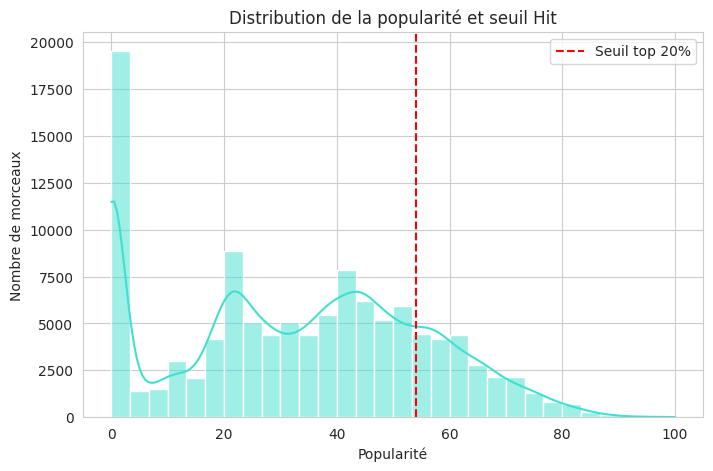

In [65]:
# Création de la variable cible (target): hit comme top 20% en popularité
seuil = df["popularity"].quantile(0.8)
df["is_hit"] = df["popularity"] >= seuil

print(f"Seuil top 20% : {seuil:.2f}\n")
print(df["is_hit"].value_counts())
print()
print(df["is_hit"].value_counts(normalize=True).round(4) * 100)

plt.figure(figsize=(8,5))
sns.histplot(df["popularity"], bins=30, kde=True, color="turquoise")
plt.axvline(seuil, color='red', linestyle='--', label='Seuil top 20%')
plt.title("Distribution de la popularité et seuil Hit")
plt.xlabel("Popularité")
plt.ylabel("Nombre de morceaux")
plt.legend()
plt.show()

# II. Analyse de fond

## 1. Visualisation de la target `is_hit`

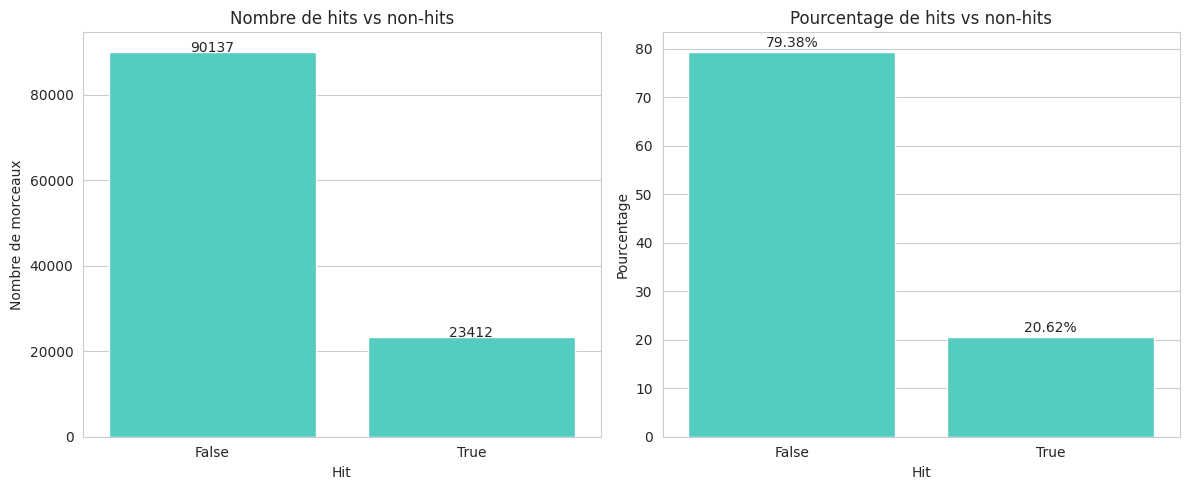

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 : effectifs
sns.countplot(x="is_hit", data=df, ax=axes[0], color="turquoise")
axes[0].set_title("Nombre de hits vs non-hits")
axes[0].set_xlabel("Hit")
axes[0].set_ylabel("Nombre de morceaux")

# Graphique 2 : pourcentages
percentages = df["is_hit"].value_counts(normalize=True) * 100

for i, v in enumerate(df["is_hit"].value_counts()):
    axes[0].text(i, v, f"{v}", ha='center')
    
for i, v in enumerate(percentages.values):
    axes[1].text(i, v + 1, f"{v:.2f}%", ha='center')

sns.barplot(
    x=percentages.index,
    y=percentages.values,
    ax=axes[1],
    color="turquoise"
)

axes[1].set_title("Pourcentage de hits vs non-hits")
axes[1].set_xlabel("Hit")
axes[1].set_ylabel("Pourcentage")

plt.tight_layout()
plt.show()

**Analyse de la variable cible `is_hit`**

La variable `is_hit` est une variable booléenne qui indique si un morceau fait partie des 20% les plus populaires.
- **False**: Le morceau ne fait pas partie des 20% les plus populaires => ce n'est pas un hit.
- **True**: Le morceau fait partie des 20% le splus populaires => c'est un hit.

**Observations**

- Environ 20% des morceaux sont classés comme "hit".
- La majorité des morceaux (environ 80%) ne sont pas des hits.

**Interprétation**

Cette répartition reflète la réalité du marché musical : seuls quelques morceaux atteignent une forte popularité.

Ce léger déséquilibre de classes devra être pris en compte lors de la modélisation.